# ML v1.5 - проверка финальной модели LightGBM из v1.4

This notebook does not search for a new winner. It validates the already selected best model from `v1.4`.

Checks included:
- `seed robustness`
- `bootstrap confidence intervals`
- `target shuffle контрольная проверка`
- `proxy time split`


In [12]:
from pathlib import Path
import sys
import subprocess
import importlib.util
import warnings

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as exc:
    print("Google Drive mount skipped:", exc)

BASE_PATH = Path("/content/drive/MyDrive/ieee-db")
DATA_FILE = BASE_PATH / "client_profile_v1_0_shuffled.csv"
V14_RESULTS_DIR = BASE_PATH / "ML" / "1.4" / "results_lightgbm_confirm"
RESULTS_DIR = BASE_PATH / "ML" / "1.5" / "results_verification"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Файл данных:", DATA_FILE)
print("V14_Папка результатов:", V14_RESULTS_DIR)
print("Папка результатов:", RESULTS_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Файл данных: /content/drive/MyDrive/ieee-db/client_profile_v1_0_shuffled.csv
V14_Папка результатов: /content/drive/MyDrive/ieee-db/ML/1.4/results_lightgbm_confirm
Папка результатов: /content/drive/MyDrive/ieee-db/ML/1.5/results_verification


In [13]:
packages = ["joblib", "matplotlib"]
for pkg in packages:
    if importlib.util.find_spec(pkg) is None:
        print(f"{pkg} not found. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
    else:
        print(f"{pkg} already installed.")

import time
import math
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)


joblib already installed.
matplotlib already installed.


## Настройки запуска

`RETRAIN_REFERENCE_IF_NEEDED=True` means that if the saved `v1.4` bundle cannot be loaded as a self-contained model, the notebook will retrain the same best configuration.

`BOOTSTRAP_N` can be reduced for a quick smoke run, but for final verification it is better to keep it at `1000+`.


In [14]:
PREFER_GPU = True
GPU_FALLBACK_TO_CPU = True

SEED_ROBUSTNESS_SEEDS = [42, 2026, 777, 1001, 2048]
SHUFFLE_SEEDS = [42, 2026, 777]
BOOTSTRAP_N = 1500
BOOTSTRAP_SEED = 20260409
HIGH_MISSING_THRESHOLD = 0.95

TOPK_RATES = [0.01, 0.03, 0.05, 0.10, 0.15]
FPR_TARGETS = [0.005, 0.01, 0.02, 0.03, 0.05]
THRESHOLDS = [0.05, 0.075, 0.10, 0.125, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

RETRAIN_REFERENCE_IF_NEEDED = True

print("PREFER_GPU:", PREFER_GPU)
print("SEED_ROBUSTNESS_SEEDS:", SEED_ROBUSTNESS_SEEDS)
print("BOOTSTRAP_N:", BOOTSTRAP_N)


PREFER_GPU: True
SEED_ROBUSTNESS_SEEDS: [42, 2026, 777, 1001, 2048]
BOOTSTRAP_N: 1500


In [15]:
# Выбираем лучшую модель по test PR-AUC из результатов v1.4.
results_file = V14_RESULTS_DIR / "ml_v1_4_lightgbm_results.csv"
if not results_file.exists():
    raise FileNotFoundError(results_file)

v14_results = pd.read_csv(results_file)
best_test_row = (
    v14_results[v14_results["split"] == "test"]
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .iloc[0]
)

BEST_MODEL_NAME = str(best_test_row["model"])
BEST_BASE_CONFIG = str(best_test_row["base_config"])
BEST_SEED = int(best_test_row["seed"])
BEST_EVAL_METRIC = str(best_test_row["eval_metric"])
BEST_EXPECTED_PR_AUC = float(best_test_row["pr_auc"])
BEST_EXPECTED_ROC_AUC = float(best_test_row["roc_auc"])

print("Best v1.4 model:")
print(best_test_row[["model", "base_config", "seed", "eval_metric", "pr_auc", "roc_auc", "best_iteration"]])


Best v1.4 model:
model             lgbm_auc_unweighted_seed2026
base_config                lgbm_auc_unweighted
seed                                      2026
eval_metric                                auc
pr_auc                                0.496665
roc_auc                               0.898653
best_iteration                             481
Name: 27, dtype: object


In [16]:
df = pd.read_csv(DATA_FILE)
print("Dataset shape:", df.shape)

TARGET_COL = "profile_fraud_label"
ID_COLS = ["client_id"]
LEAKY_COLS = ["tx_count_fraud", "fraud_rate"]

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column not found: {TARGET_COL}")

y = df[TARGET_COL].astype(int)

missing_rate = df.drop(columns=[TARGET_COL], errors="ignore").isna().mean()
high_missing_cols = missing_rate[missing_rate > HIGH_MISSING_THRESHOLD].index.tolist()
exclude_cols = [c for c in ID_COLS + LEAKY_COLS + high_missing_cols if c in df.columns]
features = [c for c in df.columns if c not in exclude_cols + [TARGET_COL]]
X = df[features].copy()

numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Excluded columns:", len(exclude_cols))
print(exclude_cols)
print("Total features:", len(features))
print("Numeric:", len(numeric_cols))
print("Categorical:", len(categorical_cols))

# Используем ту же политику случайного разбиения, что и в v1.4.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
val_size_from_trainval = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_size_from_trainval, random_state=42, stratify=y_trainval
)

print("Train:", X_train.shape, "доля fraud:", float(y_train.mean()))
print("Val:", X_val.shape, "доля fraud:", float(y_val.mean()))
print("Test:", X_test.shape, "доля fraud:", float(y_test.mean()))


Dataset shape: (174280, 95)
Excluded columns: 12
['client_id', 'id_07_mean', 'id_07_median', 'id_08_mean', 'id_08_median', 'id_21_mode', 'id_22_mode', 'id_23_mode', 'id_24_mode', 'id_25_mode', 'id_26_mode', 'id_27_mode']
Total features: 82
Numeric: 66
Categorical: 16
Train: (121996, 82) доля fraud: 0.037271713826682845
Val: (26142, 82) доля fraud: 0.037258052176574095
Test: (26142, 82) доля fraud: 0.037258052176574095


In [17]:
# One-hot preprocessing повторяет логику v1.4.
try:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("onehot", ohe),
        ]), categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

print("Обучаю preprocessing...")
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

try:
    encoded_feature_names = preprocessor.get_feature_names_out()
except Exception:
    encoded_feature_names = np.array([f"f_{i}" for i in range(X_train_enc.shape[1])])

print("Размер encoded train:", X_train_enc.shape)
print("Размер encoded val:", X_val_enc.shape)
print("Размер encoded test:", X_test_enc.shape)


Обучаю preprocessing...
Размер encoded train: (121996, 345)
Размер encoded val: (26142, 345)
Размер encoded test: (26142, 345)


In [18]:
def safe_div(num, den):
    return float(num) / float(den) if den else 0.0


def calc_metrics(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= 0.5).astype(int)
    out = {
        "pr_auc": average_precision_score(y_true, y_prob),
        "precision_0_5": precision_score(y_true, pred, zero_division=0),
        "recall_0_5": recall_score(y_true, pred, zero_division=0),
        "f1_0_5": f1_score(y_true, pred, zero_division=0),
        "pred_positive_rate": float(pred.mean()),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        out["roc_auc"] = np.nan
    for max_fpr in [0.01, 0.03, 0.05, 0.10]:
        try:
            out[f"partial_roc_auc_fpr_{str(max_fpr).replace('.', '_')}"] = roc_auc_score(y_true, y_prob, max_fpr=max_fpr)
        except Exception:
            out[f"partial_roc_auc_fpr_{str(max_fpr).replace('.', '_')}"] = np.nan
    return out


def topk_metrics(y_true, y_prob, top_rate=0.05):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    order = np.argsort(-y_prob)
    k = max(1, int(np.ceil(len(y_true) * top_rate)))
    idx = order[:k]
    fraud_found = int(y_true[idx].sum())
    return {
        "top_rate": top_rate,
        "top_k": k,
        "top_precision": fraud_found / k,
        "top_recall": safe_div(fraud_found, int(y_true.sum())),
        "fraud_found": fraud_found,
    }


def roc_operating_points(y_true, y_prob, targets=None):
    if targets is None:
        targets = FPR_TARGETS
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    rows = []
    if pd.Series(y_true).nunique() < 2:
        for target_fpr in targets:
            rows.append({
                "target_fpr": target_fpr,
                "actual_fpr": np.nan,
                "recall_at_fpr": np.nan,
                "threshold": np.nan,
                "precision_at_fpr": np.nan,
                "pred_positive_rate": np.nan,
                "pred_positive_count": np.nan,
            })
        return pd.DataFrame(rows)
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    for target_fpr in targets:
        valid = np.where(fpr <= target_fpr)[0]
        j = valid[-1] if len(valid) else 0
        thr = thresholds[j]
        pred = (y_prob >= thr).astype(int)
        rows.append({
            "target_fpr": target_fpr,
            "actual_fpr": float(fpr[j]),
            "recall_at_fpr": float(tpr[j]),
            "threshold": float(thr),
            "precision_at_fpr": precision_score(y_true, pred, zero_division=0),
            "pred_positive_rate": float(pred.mean()),
            "pred_positive_count": int(pred.sum()),
        })
    return pd.DataFrame(rows)


def threshold_table(model_name, split_name, y_true, y_prob):
    rows = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    for thr in THRESHOLDS:
        pred = (y_prob >= thr).astype(int)
        rows.append({
            "model": model_name,
            "split": split_name,
            "threshold": thr,
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "pred_positive_rate": float(pred.mean()),
            "pred_positive_count": int(pred.sum()),
        })
    return pd.DataFrame(rows)


def topk_table(model_name, split_name, y_true, y_prob):
    rows = []
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    order = np.argsort(-y_prob)
    n = len(y_true)
    positives = int(y_true.sum())
    for rate in TOPK_RATES:
        k = max(1, int(math.ceil(n * rate)))
        idx = order[:k]
        fraud_found = int(y_true[idx].sum())
        rows.append({
            "model": model_name,
            "split": split_name,
            "top_rate": rate,
            "top_k": k,
            "fraud_found": fraud_found,
            "fraud_total": positives,
            "precision_at_k": fraud_found / k,
            "recall_at_k": safe_div(fraud_found, positives),
        })
    return pd.DataFrame(rows)


In [19]:
# Конфигурации из v1.4 нужны для точного воспроизведения лучшей модели.
base_params = dict(
    objective="binary",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=80,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=2.0,
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
)

regularized_params = dict(
    objective="binary",
    n_estimators=3500,
    learning_rate=0.025,
    num_leaves=31,
    min_child_samples=120,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=4.0,
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
)

more_leaves_params = dict(
    objective="binary",
    n_estimators=3500,
    learning_rate=0.025,
    num_leaves=95,
    min_child_samples=100,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=3.0,
    class_weight="balanced",
    n_jobs=-1,
    verbose=-1,
)

unweighted_auc_params = dict(
    objective="binary",
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=63,
    min_child_samples=80,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=2.0,
    class_weight=None,
    n_jobs=-1,
    verbose=-1,
)

CONFIG_LIBRARY = {
    "lgbm_pr_default": {"params": base_params, "eval_metric": "average_precision", "early_stopping_rounds": 150},
    "lgbm_auc_default": {"params": base_params, "eval_metric": "auc", "early_stopping_rounds": 150},
    "lgbm_auc_more_leaves": {"params": more_leaves_params, "eval_metric": "auc", "early_stopping_rounds": 150},
    "lgbm_pr_regularized": {"params": regularized_params, "eval_metric": "average_precision", "early_stopping_rounds": 150},
    "lgbm_auc_unweighted": {"params": unweighted_auc_params, "eval_metric": "auc", "early_stopping_rounds": 150},
}

if BEST_BASE_CONFIG not in CONFIG_LIBRARY:
    raise KeyError(f"Unknown base_config from v1.4 results: {BEST_BASE_CONFIG}")

BEST_CFG = CONFIG_LIBRARY[BEST_BASE_CONFIG]
print("Verification config:", BEST_BASE_CONFIG)
print(BEST_CFG)


Verification config: lgbm_auc_unweighted
{'params': {'objective': 'binary', 'n_estimators': 3000, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 80, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'class_weight': None, 'n_jobs': -1, 'verbose': -1}, 'eval_metric': 'auc', 'early_stopping_rounds': 150}


In [20]:
def fit_one_lgbm(seed, cfg=None, Xtr=None, ytr=None, Xva=None, yva=None, prefer_gpu=True, shuffle_mode=False):
    if cfg is None:
        cfg = BEST_CFG
    if Xtr is None:
        Xtr = X_train_enc
    if ytr is None:
        ytr = y_train
    if Xva is None:
        Xva = X_val_enc
    if yva is None:
        yva = y_val

    fit_params = dict(cfg["params"])
    fit_params["random_state"] = seed
    fit_params["feature_fraction_seed"] = seed
    fit_params["bagging_seed"] = seed
    fit_params["data_random_seed"] = seed

    if Использовать GPU:
        attempts = [
            ("gpu", {**fit_params, "device_type": "gpu", "gpu_use_dp": False}),
            ("cpu_after_gpu_fallback", {**fit_params, "device_type": "cpu"}),
        ]
    else:
        attempts = [("cpu", {**fit_params, "device_type": "cpu"})]

    last_exc = None
    for used_device, params in attempts:
        start = time.time()
        try:
            model = LGBMClassifier(**params)
            model.fit(
                Xtr,
                ytr,
                eval_set=[(Xva, yva)],
                eval_metric=cfg["eval_metric"],
                callbacks=[lgb.early_stopping(cfg["early_stopping_rounds"]), lgb.log_evaluation(200)],
            )
            return model, time.time() - start, used_device, None
        except Exception as exc:
            print(f"Attempt {used_device} failed for seed={seed}: {repr(exc)}")
            last_exc = exc
    raise last_exc


In [21]:
# Сначала загружаем bundle v1.4, иначе переобучаем лучшую конфигурацию.
reference_bundle_path = V14_RESULTS_DIR / "ml_v1_4_best_by_pr_auc.joblib"
reference_model = None
reference_source = None

if reference_bundle_path.exists():
    try:
        reference_bundle = joblib.load(reference_bundle_path)
        print("Загрузкаed bundle type:", type(reference_bundle))
        if isinstance(reference_bundle, dict):
            print("Bundle keys:", list(reference_bundle.keys()))
            for key in ["model", "best_model", "estimator", "clf"]:
                if key in reference_bundle:
                    reference_model = reference_bundle[key]
                    reference_source = f"loaded_bundle_{key}"
                    break
        else:
            reference_model = reference_bundle
            reference_source = "loaded_bundle_object"
    except Exception as exc:
        print("Could not load reference bundle cleanly:", repr(exc))

if reference_model is None:
    if not RETRAIN_REFERENCE_IF_NEEDED:
        raise RuntimeError("Reference bundle not usable and retrain disabled")
    print("Retraining reference model from best v1.4 configuration...")
    reference_model, ref_elapsed, ref_used_device, _ = fit_one_lgbm(BEST_SEED, prefer_gpu=PREFER_GPU)
    reference_source = f"retrained_{ref_used_device}"

reference_val_prob = reference_model.predict_proba(X_val_enc)[:, 1]
reference_test_prob = reference_model.predict_proba(X_test_enc)[:, 1]
reference_metrics_val = calc_metrics(y_val, reference_val_prob)
reference_metrics_test = calc_metrics(y_test, reference_test_prob)
reference_roc_ops_test = roc_operating_points(y_test, reference_test_prob)

reference_rows = []
for split_name, metric_dict in [("val", reference_metrics_val), ("test", reference_metrics_test)]:
    row = {"model": BEST_MODEL_NAME, "base_config": BEST_BASE_CONFIG, "seed": BEST_SEED, "split": split_name, "source": reference_source}
    row.update(metric_dict)
    reference_rows.append(row)

reference_df = pd.DataFrame(reference_rows)
reference_df.to_csv(RESULTS_DIR / "ml_v1_5_reference_model_metrics.csv", index=False)
reference_roc_ops_test.to_csv(RESULTS_DIR / "ml_v1_5_reference_model_roc_ops.csv", index=False)

print("Reference model source:", reference_source)
print("Reference test metrics:")
display(reference_df[reference_df["split"] == "test"])
print("Expected from v1.4: PR-AUC=", BEST_EXPECTED_PR_AUC, " ROC-AUC=", BEST_EXPECTED_ROC_AUC)


Загрузкаed bundle type: <class 'dict'>
Bundle keys: ['model_name', 'model', 'preprocessor', 'features', 'numeric_cols', 'categorical_cols', 'selection_rule']
Reference model source: loaded_bundle_model
Reference test metrics:


,model,base_config,seed,split,source,pr_auc,precision_0_5,recall_0_5,f1_0_5,pred_positive_rate,roc_auc,partial_roc_auc_fpr_0_01,partial_roc_auc_fpr_0_03,partial_roc_auc_fpr_0_05,partial_roc_auc_fpr_0_1
1,lgbm_auc_unweighted_seed2026,lgbm_auc_unweighted,2026,test,loaded_bundle_model,0.496665,0.752907,0.265914,0.39302,0.013159,0.898653,0.64286,0.712143,0.744333,0.788655


Expected from v1.4: PR-AUC= 0.4966652740942851  ROC-AUC= 0.8986526557957629


In [22]:
# Устойчивость к seed.
seed_rows = []
for seed in SEED_ROBUSTNESS_SEEDS:
    print("\nTraining seed robustness model, seed=", seed)
    model, elapsed, used_device, _ = fit_one_lgbm(seed, prefer_gpu=PREFER_GPU)
    for split_name, yy, XX in [("val", y_val, X_val_enc), ("test", y_test, X_test_enc)]:
        prob = model.predict_proba(XX)[:, 1]
        row = {"seed": seed, "split": split_name, "used_device": used_device, "elapsed_sec": elapsed}
        row.update(calc_metrics(yy, prob))
        roc_ops = roc_operating_points(yy, prob)
        for target_fpr in [0.01, 0.03, 0.05]:
            sub = roc_ops[roc_ops["target_fpr"] == target_fpr].iloc[0]
            row[f"recall_at_fpr_{str(target_fpr).replace('.', '_')}"] = float(sub["recall_at_fpr"])
            row[f"precision_at_fpr_{str(target_fpr).replace('.', '_')}"] = float(sub["precision_at_fpr"])
        seed_rows.append(row)

seed_df = pd.DataFrame(seed_rows)
seed_df.to_csv(RESULTS_DIR / "ml_v1_5_seed_robustness.csv", index=False)

seed_test_numeric = seed_df[seed_df["split"] == "test"].select_dtypes(include=[np.number])
seed_сводка = (
    seed_test_numeric
    .agg(["mean", "std", "min", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)
seed_сводка.to_csv(RESULTS_DIR / "ml_v1_5_seed_robustness_сводка.csv", index=False)

print("Seed robustness test rows:")
display(seed_df[seed_df["split"] == "test"].sort_values("pr_auc", ascending=False))
print("Seed robustness сводка:")
display(seed_сводка)



Training seed robustness model, seed= 42
Attempt gpu failed for seed=42: LightGBMError('No OpenCL device found')
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.894143	valid_0's binary_logloss: 0.103367
[400]	valid_0's auc: 0.900302	valid_0's binary_logloss: 0.101047
[600]	valid_0's auc: 0.900298	valid_0's binary_logloss: 0.100758
Early stopping, best iteration is:
[453]	valid_0's auc: 0.900916	valid_0's binary_logloss: 0.100771

Training seed robustness model, seed= 2026
Attempt gpu failed for seed=2026: LightGBMError('No OpenCL device found')
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.893748	valid_0's binary_logloss: 0.10348
[400]	valid_0's auc: 0.900509	valid_0's binary_logloss: 0.100912
[600]	valid_0's auc: 0.900341	valid_0's binary_logloss: 0.100662
Early stopping, best iteration is:
[481]	valid_0's auc: 0.901617	valid_0's binary_logloss: 0.100495

Training seed robustness model, seed= 777
Attempt gpu 

,seed,split,used_device,elapsed_sec,pr_auc,precision_0_5,recall_0_5,f1_0_5,pred_positive_rate,roc_auc,partial_roc_auc_fpr_0_01,partial_roc_auc_fpr_0_03,partial_roc_auc_fpr_0_05,partial_roc_auc_fpr_0_1,recall_at_fpr_0_01,precision_at_fpr_0_01,recall_at_fpr_0_03,precision_at_fpr_0_03,recall_at_fpr_0_05,precision_at_fpr_0_05
3,2026,test,cpu_after_gpu_fallback,31.483304,0.496665,0.752907,0.265914,0.393020,0.013159,0.898653,0.642860,0.712143,0.744333,0.788655,0.414784,0.616794,0.561602,0.420769,0.643737,0.332626
7,1001,test,cpu_after_gpu_fallback,30.057907,0.494838,0.735211,0.267967,0.392777,0.013580,0.897982,0.642686,0.712779,0.745142,0.789252,0.413758,0.617152,0.569815,0.423664,0.639630,0.333869
1,42,test,cpu_after_gpu_fallback,28.410820,0.493990,0.737143,0.264887,0.389728,0.013388,0.898516,0.641813,0.711661,0.743352,0.788489,0.410678,0.616333,0.564682,0.421456,0.637577,0.330495
5,777,test,cpu_after_gpu_fallback,27.705367,0.491949,0.729345,0.262834,0.386415,0.013427,0.898355,0.640020,0.712338,0.744019,0.788152,0.408624,0.613251,0.560575,0.419677,0.640657,0.332268
9,2048,test,cpu_after_gpu_fallback,27.758529,0.489588,0.732955,0.264887,0.389140,0.013465,0.897720,0.638672,0.708771,0.741225,0.786774,0.410678,0.614439,0.555441,0.418083,0.639630,0.332977


Seed robustness сводка:


,metric,mean,std,min,max
0,seed,1178.800000,860.032964,42.000000,2048.000000
1,elapsed_sec,29.083185,1.644371,27.705367,31.483304
2,pr_auc,0.493406,0.002726,0.489588,0.496665
3,precision_0_5,0.737512,0.009082,0.729345,0.752907
4,recall_0_5,0.265298,0.001865,0.262834,0.267967
5,f1_0_5,0.390216,0.002750,0.386415,0.393020
6,pred_positive_rate,0.013404,0.000154,0.013159,0.013580
7,roc_auc,0.898245,0.000386,0.897720,0.898653
8,partial_roc_auc_fpr_0_01,0.641210,0.001811,0.638672,0.642860
9,partial_roc_auc_fpr_0_03,0.711538,0.001598,0.708771,0.712779


Bootstrap: 250/1500
Bootstrap: 500/1500
Bootstrap: 750/1500
Bootstrap: 1000/1500
Bootstrap: 1250/1500
Bootstrap: 1500/1500
Bootstrap valid samples: 1500


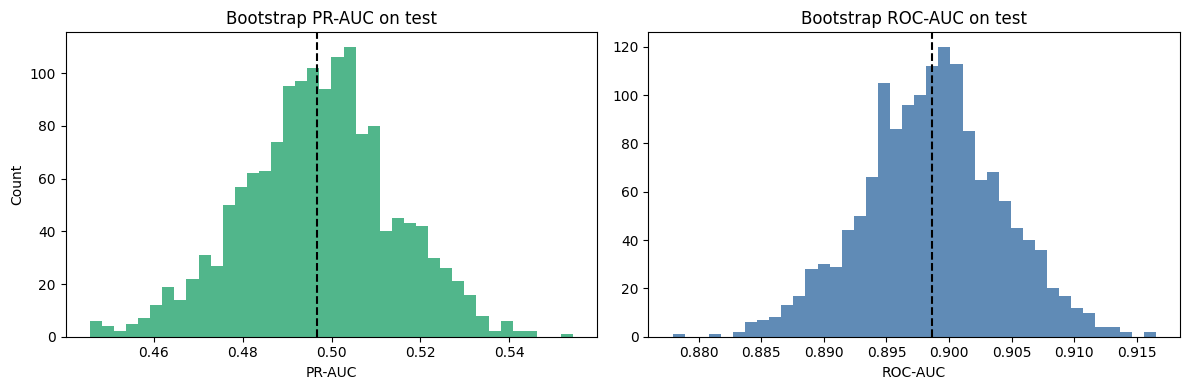

Bootstrap сводка:


,metric,mean,std,q02_5,q50,q97_5
0,roc_auc,0.898632,0.005508,0.887574,0.898695,0.909410
1,pr_auc,0.497031,0.016970,0.462228,0.497280,0.529810
2,top5_precision,0.419485,0.016232,0.387615,0.419725,0.452236
3,top5_recall,0.563670,0.014727,0.534224,0.564180,0.591505
4,recall_at_fpr_0_01,0.416450,0.019289,0.377659,0.416543,0.454877
5,precision_at_fpr_0_01,0.617828,0.013495,0.590347,0.617960,0.643577
6,recall_at_fpr_0_03,0.562932,0.016510,0.530600,0.563266,0.593998
7,precision_at_fpr_0_03,0.420948,0.010866,0.399121,0.421032,0.442129
8,recall_at_fpr_0_05,0.642261,0.016728,0.609870,0.642704,0.674137
9,precision_at_fpr_0_05,0.332096,0.009472,0.312854,0.332091,0.350663


In [23]:
# Bootstrap-интервалы на test-прогнозах опорной модели.
rng = np.random.default_rng(BOOTSTRAP_SEED)
y_test_np = np.asarray(y_test)
ref_prob_np = np.asarray(reference_test_prob)

boot_rows = []
for i in range(BOOTSTRAP_N):
    idx = rng.integers(0, len(y_test_np), len(y_test_np))
    yb = y_test_np[idx]
    pb = ref_prob_np[idx]
    if pd.Series(yb).nunique() < 2:
        continue

    row = {
        "bootstrap_iter": i,
        "roc_auc": roc_auc_score(yb, pb),
        "pr_auc": average_precision_score(yb, pb),
    }
    top5 = topk_metrics(yb, pb, top_rate=0.05)
    row["top5_precision"] = top5["top_precision"]
    row["top5_recall"] = top5["top_recall"]

    roc_ops = roc_operating_points(yb, pb, targets=[0.01, 0.03, 0.05])
    for target_fpr in [0.01, 0.03, 0.05]:
        sub = roc_ops[roc_ops["target_fpr"] == target_fpr].iloc[0]
        row[f"recall_at_fpr_{str(target_fpr).replace('.', '_')}"] = float(sub["recall_at_fpr"])
        row[f"precision_at_fpr_{str(target_fpr).replace('.', '_')}"] = float(sub["precision_at_fpr"])

    boot_rows.append(row)
    if (i + 1) % 250 == 0:
        print(f"Bootstrap: {i + 1}/{BOOTSTRAP_N}")

boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(RESULTS_DIR / "ml_v1_5_bootstrap_samples.csv", index=False)
print("Bootstrap valid samples:", len(boot_df))

сводка_rows = []
for col in [c for c in boot_df.columns if c != "bootstrap_iter"]:
    vals = boot_df[col].dropna().values
    сводка_rows.append({
        "metric": col,
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals, ddof=1)),
        "q02_5": float(np.quantile(vals, 0.025)),
        "q50": float(np.quantile(vals, 0.50)),
        "q97_5": float(np.quantile(vals, 0.975)),
    })
boot_сводка = pd.DataFrame(сводка_rows)
boot_сводка.to_csv(RESULTS_DIR / "ml_v1_5_bootstrap_сводка.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(boot_df["pr_auc"], bins=40, color="#3a7", alpha=0.85)
axes[0].axvline(reference_metrics_test["pr_auc"], color="black", linestyle="--")
axes[0].set_title("Bootstrap PR-AUC on test")
axes[0].set_xlabel("PR-AUC")
axes[0].set_ylabel("Count")
axes[1].hist(boot_df["roc_auc"], bins=40, color="#47a", alpha=0.85)
axes[1].axvline(reference_metrics_test["roc_auc"], color="black", linestyle="--")
axes[1].set_title("Bootstrap ROC-AUC on test")
axes[1].set_xlabel("ROC-AUC")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ml_v1_5_bootstrap_hist.png", dpi=160, bbox_inches="tight")
plt.show()

print("Bootstrap сводка:")
display(boot_сводка)


In [24]:
# 3. Проверка с перемешанной целевой переменной
shuffle_rows = []
rng = np.random.default_rng(20260409)

y_train_np = np.asarray(y_train)
y_val_np = np.asarray(y_val)
y_test_np = np.asarray(y_test)

for seed in SHUFFLE_SEEDS:
    print("\nTarget shuffle run, seed=", seed)
    y_train_shuffled = rng.permutation(y_train_np)
    y_val_shuffled = rng.permutation(y_val_np)
    model, elapsed, used_device, _ = fit_one_lgbm(
        seed,
        Xtr=X_train_enc,
        ytr=y_train_shuffled,
        Xva=X_val_enc,
        yva=y_val_shuffled,
        prefer_gpu=PREFER_GPU,
    )
    val_prob = model.predict_proba(X_val_enc)[:, 1]
    test_prob = model.predict_proba(X_test_enc)[:, 1]

    row_val = {"seed": seed, "split": "val_real_labels_eval", "used_device": used_device, "elapsed_sec": elapsed}
    row_val.update(calc_metrics(y_val_np, val_prob))
    shuffle_rows.append(row_val)

    row_test = {"seed": seed, "split": "test_real_labels_eval", "used_device": used_device, "elapsed_sec": elapsed}
    row_test.update(calc_metrics(y_test_np, test_prob))
    shuffle_rows.append(row_test)

shuffle_df = pd.DataFrame(shuffle_rows)
shuffle_df.to_csv(RESULTS_DIR / "ml_v1_5_target_shuffle.csv", index=False)

shuffle_test_numeric = shuffle_df[shuffle_df["split"] == "test_real_labels_eval"].select_dtypes(include=[np.number])
shuffle_сводка = (
    shuffle_test_numeric
    .agg(["mean", "std", "min", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "metric"})
)
shuffle_сводка.to_csv(RESULTS_DIR / "ml_v1_5_target_shuffle_сводка.csv", index=False)

print("Target shuffle test results:")
display(shuffle_df[shuffle_df["split"] == "test_real_labels_eval"])
print("Target shuffle сводка:")
display(shuffle_сводка)
print("Random PR-AUC baseline (fraud rate):", float(y_test_np.mean()))



Target shuffle run, seed= 42
Attempt gpu failed for seed=42: LightGBMError('No OpenCL device found')
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.491371	valid_0's binary_logloss: 0.159146

Target shuffle run, seed= 2026
Attempt gpu failed for seed=2026: LightGBMError('No OpenCL device found')
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[3]	valid_0's auc: 0.502332	valid_0's binary_logloss: 0.159116

Target shuffle run, seed= 777
Attempt gpu failed for seed=777: LightGBMError('No OpenCL device found')
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[1]	valid_0's auc: 0.518573	valid_0's binary_logloss: 0.159112
Target shuffle test results:


,seed,split,used_device,elapsed_sec,pr_auc,precision_0_5,recall_0_5,f1_0_5,pred_positive_rate,roc_auc,partial_roc_auc_fpr_0_01,partial_roc_auc_fpr_0_03,partial_roc_auc_fpr_0_05,partial_roc_auc_fpr_0_1
1,42,test_real_labels_eval,cpu_after_gpu_fallback,5.985274,0.056674,0.0,0.0,0.0,0.0,0.436082,0.514446,0.533051,0.546770,0.555487
3,2026,test_real_labels_eval,cpu_after_gpu_fallback,9.140810,0.043509,0.0,0.0,0.0,0.0,0.495023,0.503499,0.512466,0.517677,0.527560
5,777,test_real_labels_eval,cpu_after_gpu_fallback,5.889720,0.036643,0.0,0.0,0.0,0.0,0.428882,0.499645,0.507923,0.515414,0.516234


Target shuffle сводка:


,metric,mean,std,min,max
0,seed,948.333333,1003.035559,42.000000,2026.000000
1,elapsed_sec,7.005268,1.850050,5.889720,9.140810
2,pr_auc,0.045609,0.010179,0.036643,0.056674
3,precision_0_5,0.000000,0.000000,0.000000,0.000000
4,recall_0_5,0.000000,0.000000,0.000000,0.000000
5,f1_0_5,0.000000,0.000000,0.000000,0.000000
6,pred_positive_rate,0.000000,0.000000,0.000000,0.000000
7,roc_auc,0.453329,0.036287,0.428882,0.495023
8,partial_roc_auc_fpr_0_01,0.505864,0.007678,0.499645,0.514446
9,partial_roc_auc_fpr_0_03,0.517813,0.013390,0.507923,0.533051


Random PR-AUC baseline (fraud rate): 0.037258052176574095


## Proxy Time Split

The final profile table does not contain an explicit absolute client timestamp, so this check uses a proxy time split based on the `D1n` component embedded in `client_id`.

This is an additional robustness check, not a replacement for a real future holdout.


In [25]:
# Proxy time split.
proxy_df = df.copy()
if "client_id" not in proxy_df.columns:
    raise ValueError("client_id is required for proxy time split")

proxy_df["client_anchor_proxy_day"] = pd.to_numeric(
    proxy_df["client_id"].astype(str).str.rsplit("_", n=1).str[-1],
    errors="coerce"
)

proxy_df = proxy_df[proxy_df["client_anchor_proxy_day"].notna()].copy()
if proxy_df.empty:
    raise ValueError("Proxy time split cannot run: no valid proxy day extracted from client_id")
proxy_df = proxy_df.sort_values(["client_anchor_proxy_day", "client_id"], kind="mergesort").reset_index(drop=True)
print("Proxy-time rows:", proxy_df.shape)
print(proxy_df[["client_id", "client_anchor_proxy_day"]].head())
print(proxy_df[["client_id", "client_anchor_proxy_day"]].tail())

proxy_target = proxy_df[TARGET_COL].astype(int)
proxy_features = proxy_df[features].copy()

n = len(proxy_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train_t = proxy_features.iloc[:train_end].copy()
y_train_t = proxy_target.iloc[:train_end].copy()
X_val_t = proxy_features.iloc[train_end:val_end].copy()
y_val_t = proxy_target.iloc[train_end:val_end].copy()
X_test_t = proxy_features.iloc[val_end:].copy()
y_test_t = proxy_target.iloc[val_end:].copy()

print("Proxy train:", X_train_t.shape, "доля fraud:", float(y_train_t.mean()))
print("Proxy val:", X_val_t.shape, "доля fraud:", float(y_val_t.mean()))
print("Proxy test:", X_test_t.shape, "доля fraud:", float(y_test_t.mean()))
if len(pd.Series(y_train_t).unique()) < 2 or len(pd.Series(y_val_t).unique()) < 2 or len(pd.Series(y_test_t).unique()) < 2:
    raise ValueError("Proxy time split produced a one-class segment; cannot evaluate ROC-based metrics safely")

try:
    ohe_t = OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=True)
except TypeError:
    ohe_t = OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse=True)

preprocessor_t = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("onehot", ohe_t),
        ]), categorical_cols),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

X_train_t_enc = preprocessor_t.fit_transform(X_train_t)
X_val_t_enc = preprocessor_t.transform(X_val_t)
X_test_t_enc = preprocessor_t.transform(X_test_t)

proxy_model, proxy_elapsed, proxy_used_device, _ = fit_one_lgbm(
    BEST_SEED,
    Xtr=X_train_t_enc,
    ytr=y_train_t,
    Xva=X_val_t_enc,
    yva=y_val_t,
    prefer_gpu=PREFER_GPU,
)
proxy_val_prob = proxy_model.predict_proba(X_val_t_enc)[:, 1]
proxy_test_prob = proxy_model.predict_proba(X_test_t_enc)[:, 1]

proxy_rows = []
for split_name, yy, prob in [("val", y_val_t, proxy_val_prob), ("test", y_test_t, proxy_test_prob)]:
    row = {"model": BEST_BASE_CONFIG, "split": split_name, "used_device": proxy_used_device, "elapsed_sec": proxy_elapsed, "split_type": "proxy_time_split"}
    row.update(calc_metrics(yy, prob))
    proxy_rows.append(row)

proxy_results_df = pd.DataFrame(proxy_rows)
proxy_thresholds_df = pd.concat([
    threshold_table("proxy_time_model", "val", y_val_t, proxy_val_prob),
    threshold_table("proxy_time_model", "test", y_test_t, proxy_test_prob),
], ignore_index=True)
proxy_topk_df = pd.concat([
    topk_table("proxy_time_model", "val", y_val_t, proxy_val_prob),
    topk_table("proxy_time_model", "test", y_test_t, proxy_test_prob),
], ignore_index=True)

proxy_roc_rows = []
for split_name, yy, prob in [("val", y_val_t, proxy_val_prob), ("test", y_test_t, proxy_test_prob)]:
    ops = roc_operating_points(yy, prob)
    ops.insert(0, "split", split_name)
    ops.insert(0, "model", "proxy_time_model")
    proxy_roc_rows.append(ops)
proxy_roc_df = pd.concat(proxy_roc_rows, ignore_index=True)

proxy_results_df.to_csv(RESULTS_DIR / "ml_v1_5_proxy_time_split_results.csv", index=False)
proxy_thresholds_df.to_csv(RESULTS_DIR / "ml_v1_5_proxy_time_split_thresholds.csv", index=False)
proxy_topk_df.to_csv(RESULTS_DIR / "ml_v1_5_proxy_time_split_topk.csv", index=False)
proxy_roc_df.to_csv(RESULTS_DIR / "ml_v1_5_proxy_time_split_roc_ops.csv", index=False)

print("Proxy time split results:")
display(proxy_results_df)
print("Proxy time split ROC operating points (test):")
display(proxy_roc_df[proxy_roc_df["split"] == "test"])


Proxy-time rows: (174280, 96)
           client_id  client_anchor_proxy_day
0  10023_264.0_-9999                    -9999
1  10023_325.0_-9999                    -9999
2       10023__-9999                    -9999
3  10057_123.0_-9999                    -9999
4  10057_269.0_-9999                    -9999
             client_id  client_anchor_proxy_day
174275  9803_472.0_182                      182
174276  9885_264.0_182                      182
174277       9917__182                      182
174278  9954_269.0_182                      182
174279  9992_485.0_182                      182
Proxy train: (121995, 82) доля fraud: 0.03256690847985573
Proxy val: (26143, 82) доля fraud: 0.050644531997092915
Proxy test: (26142, 82) доля fraud: 0.04582663912478005
Attempt gpu failed for seed=2026: LightGBMError('No OpenCL device found')
Training until validation scores don't improve for 150 rounds
[200]	valid_0's auc: 0.885447	valid_0's binary_logloss: 0.132811
Early stopping, best iteration is:


,model,split,used_device,elapsed_sec,split_type,pr_auc,precision_0_5,recall_0_5,f1_0_5,pred_positive_rate,roc_auc,partial_roc_auc_fpr_0_01,partial_roc_auc_fpr_0_03,partial_roc_auc_fpr_0_05,partial_roc_auc_fpr_0_1
0,lgbm_auc_unweighted,val,cpu_after_gpu_fallback,18.214866,proxy_time_split,0.498540,0.763466,0.246224,0.372359,0.016333,0.885626,0.625368,0.690532,0.722137,0.769508
1,lgbm_auc_unweighted,test,cpu_after_gpu_fallback,18.214866,proxy_time_split,0.443222,0.705167,0.193656,0.303864,0.012585,0.885119,0.603341,0.668837,0.702999,0.751584


Proxy time split ROC operating points (test):


,model,split,target_fpr,actual_fpr,recall_at_fpr,threshold,precision_at_fpr,pred_positive_rate,pred_positive_count
5,proxy_time_model,test,0.005,0.004851,0.227880,0.453904,0.692893,0.015072,394
6,proxy_time_model,test,0.010,0.009982,0.320534,0.323788,0.606635,0.024214,633
7,proxy_time_model,test,0.020,0.019764,0.421536,0.212171,0.506012,0.038176,998
8,proxy_time_model,test,0.030,0.029907,0.488314,0.158254,0.439519,0.050914,1331
9,proxy_time_model,test,0.050,0.049992,0.562604,0.107355,0.350859,0.073483,1921


In [26]:
print("Saved verification outputs to:", RESULTS_DIR)
for p in sorted(RESULTS_DIR.glob("ml_v1_5_*")):
    print(p.name)


Saved verification outputs to: /content/drive/MyDrive/ieee-db/ML/1.5/results_verification
ml_v1_5_bootstrap_hist.png
ml_v1_5_bootstrap_samples.csv
ml_v1_5_bootstrap_сводка.csv
ml_v1_5_proxy_time_split_results.csv
ml_v1_5_proxy_time_split_roc_ops.csv
ml_v1_5_proxy_time_split_thresholds.csv
ml_v1_5_proxy_time_split_topk.csv
ml_v1_5_reference_model_metrics.csv
ml_v1_5_reference_model_roc_ops.csv
ml_v1_5_seed_robustness.csv
ml_v1_5_seed_robustness_сводка.csv
ml_v1_5_target_shuffle.csv
ml_v1_5_target_shuffle_сводка.csv
